In [1]:
from OtherZonesMEFAnalysis import OtherZonesAnalysis

In [2]:
#PJM data
path = "DATAISOS/PJM.xlsx"
sheet_name="Published Hourly Data"
PJM_analysis = OtherZonesAnalysis(path,sheet_name=sheet_name)
df = PJM_analysis.load_and_clean_data()

Loading data from DATAISOS/PJM.xlsx...
🔧 Removing outliers (IQR) and interpolating gaps...
🧮 Calculating aggregate renewable and non-renewable generation...
✅ Data loaded and cleaned successfully.
   Date range: 2019-01-01 → 2025-12-31
   Observations: 61345
   Columns: ['Date', 'D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas', 'Gen_Nuclear', 'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil', 'Hour', 'renewable_gen', 'non_renewable_gen', 'hourly_emissions_mlb', 'hourly_generation_mkwh', 'hourly_generation_renewables_mkwh', 'hourly_generation_nonrenewables_mkwh', 'T']


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved Generation Mix plot to images_msm/PJM_Gen.eps
Saved Generation Mix plot to images_msm/PJM_Gen.svg


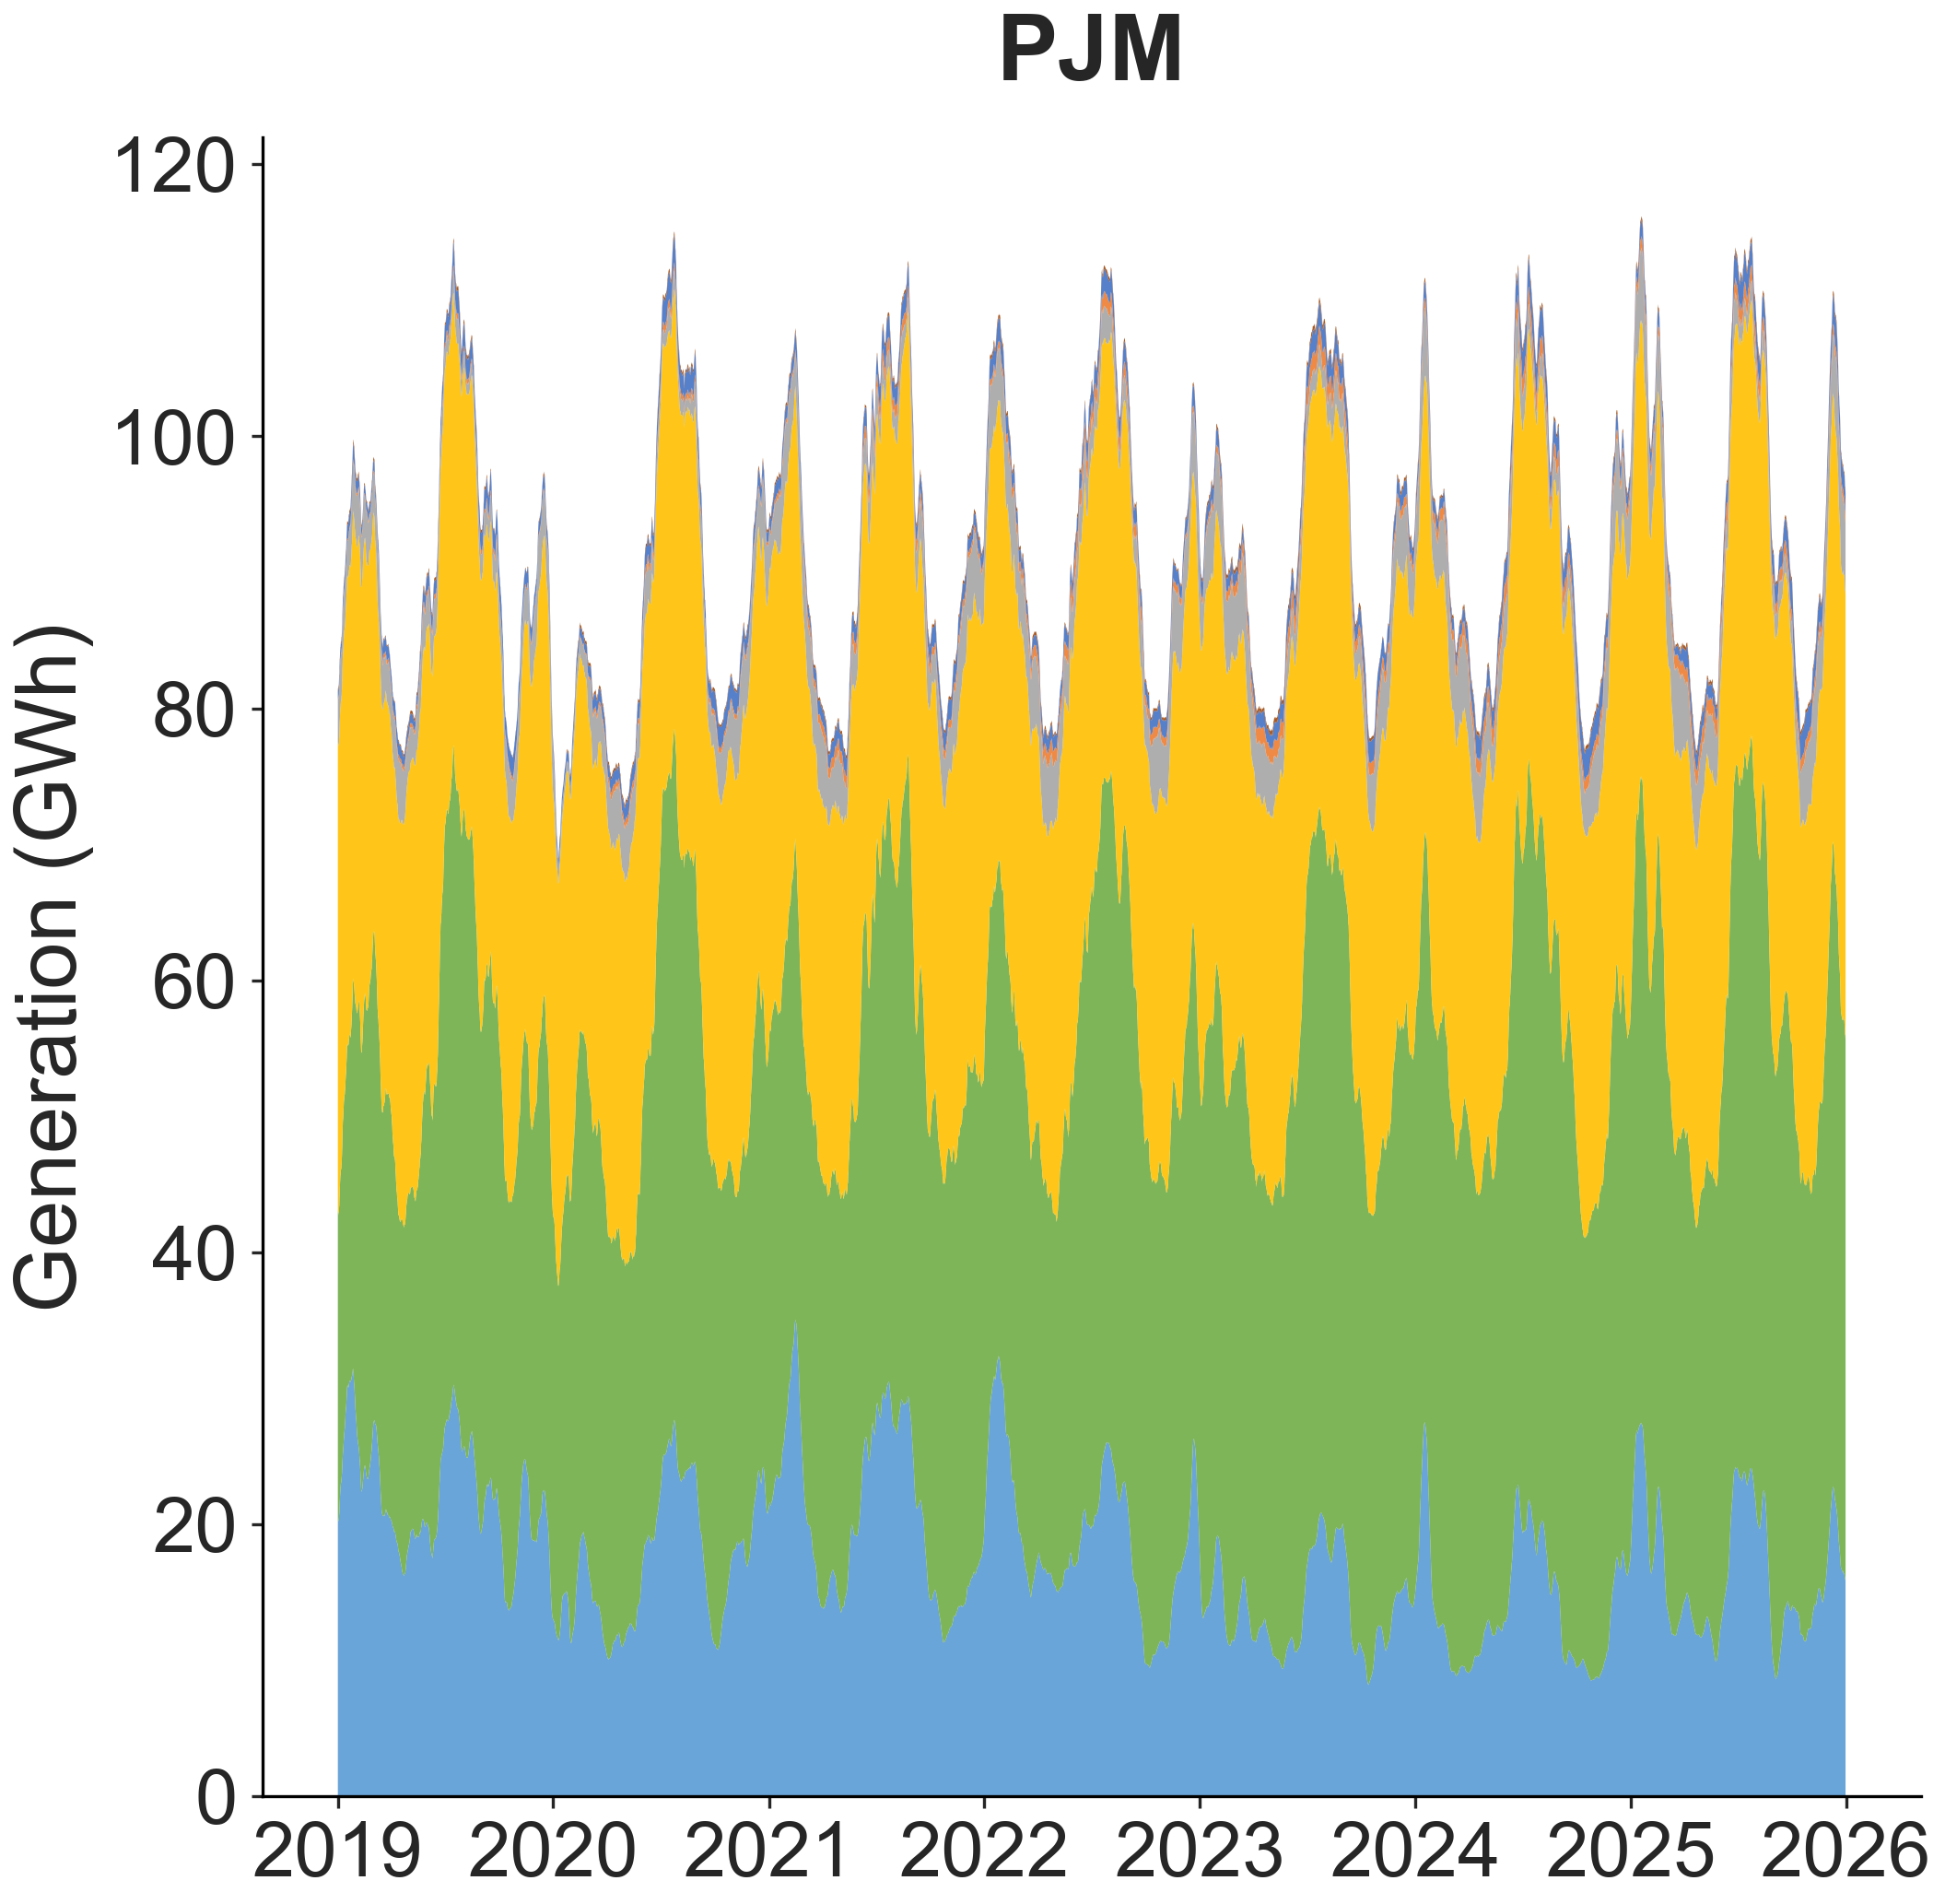

In [3]:
PJM_analysis.plot_generation_mix(show_legend=False)

In [4]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Date,61345,2022-07-01 23:59:59.999999,2019-01-01 00:00:00,2020-10-01 00:00:00,2022-07-02 00:00:00,2024-04-01 00:00:00,2025-12-31 00:00:00,NaN
D,61345.0,91312.650183,56260.0,80528.0,88937.0,100289.0,130004.0,15021.091627
NG,61345.0,95035.508892,63178.0,84057.0,92532.0,104031.0,134038.0,15277.641492
daily_emissions,61345.0,32845.340642,12972.627785,26077.476162,31049.553139,38009.508608,55936.172687,8909.150616
Gen_Coal,61345.0,17641.026514,5736.0,12403.0,16285.0,21819.0,35970.0,6693.660796
Gen_Gas,61345.0,38084.209349,13346.0,31423.0,36950.0,43470.0,61593.0,9310.109303
Gen_Nuclear,61345.0,31154.085427,25192.0,29694.0,31726.0,32806.0,35180.0,2143.003856
Gen_Wind,61345.0,3244.017565,8.0,1368.0,2719.0,4804.0,9891.0,2253.020456
Gen_Sun,61345.0,712.601614,0.0,8.0,44.0,1278.0,3515.0,999.95296
Gen_Others,61345.0,1270.67792,0.0,824.0,1148.0,1614.0,2801.0,560.297871


In [5]:
df.columns


Index(['Date', 'D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas',
       'Gen_Nuclear', 'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil', 'Hour',
       'renewable_gen', 'non_renewable_gen', 'hourly_emissions_mlb',
       'hourly_generation_mkwh', 'hourly_generation_renewables_mkwh',
       'hourly_generation_nonrenewables_mkwh', 'T'],
      dtype='str')

In [6]:
# extract_seasonality
df_seasonality = PJM_analysis.extract_seasonality()

Extracting seasonality...
  -> Fitting emissions...
  -> Fitting renewable gen...
  -> Fitting non renewable gen...
Seasonality extraction complete.


In [7]:
res = PJM_analysis.compute_msm_per_year()

Computing MSM per year...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...

MSM Results:
   Year  year   OLS_MEF    OLS_SE  MS_High_MEF  MS_High_SE  MS_Low_MEF  \
0  2019  2019  1.445164  0.027461     1.437203    0.014093    1.422229   
1  2020  2020  1.346434  0.021396     1.365081    0.007267    1.242337   
2  2021  2021  1.318130  0.028463     1.370522    0.007770    0.838453   
3  2022  2022  1.358027  0.030012     1.622633    0.011899    1.160287   
4  2023  2023  1.316408  0.030606     1.280000    0.016332    1.210092   
5  2024  2024  1.408271  0.027887     1.286541    0.011924    1.208438   
6  2025  2025  1.394806  0.021947     1.185523    0.010417    1.172919   

   MS_Low_SE  Avg_Emissions  
0   0.006452       0.842683  
1   0.007455       0.781091  
2   0.021700       0.824317  
3   0.005402       0.808192  
4   0.005676       0.725839  
5   0.006054       0.731597  
6   0.004085       0.776

In [8]:
res

,Year,year,OLS_MEF,OLS_SE,MS_High_MEF,MS_High_SE,MS_Low_MEF,MS_Low_SE,Avg_Emissions
0,2019,2019,1.445164,0.027461,1.437203,0.014093,1.422229,0.006452,0.842683
1,2020,2020,1.346434,0.021396,1.365081,0.007267,1.242337,0.007455,0.781091
2,2021,2021,1.318130,0.028463,1.370522,0.007770,0.838453,0.021700,0.824317
3,2022,2022,1.358027,0.030012,1.622633,0.011899,1.160287,0.005402,0.808192
4,2023,2023,1.316408,0.030606,1.280000,0.016332,1.210092,0.005676,0.725839
5,2024,2024,1.408271,0.027887,1.286541,0.011924,1.208438,0.006054,0.731597
6,2025,2025,1.394806,0.021947,1.185523,0.010417,1.172919,0.004085,0.776391


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved MEF plot to images_msm/PJM_MEF.eps
Saved MEF plot to images_msm/PJM_MEF.svg


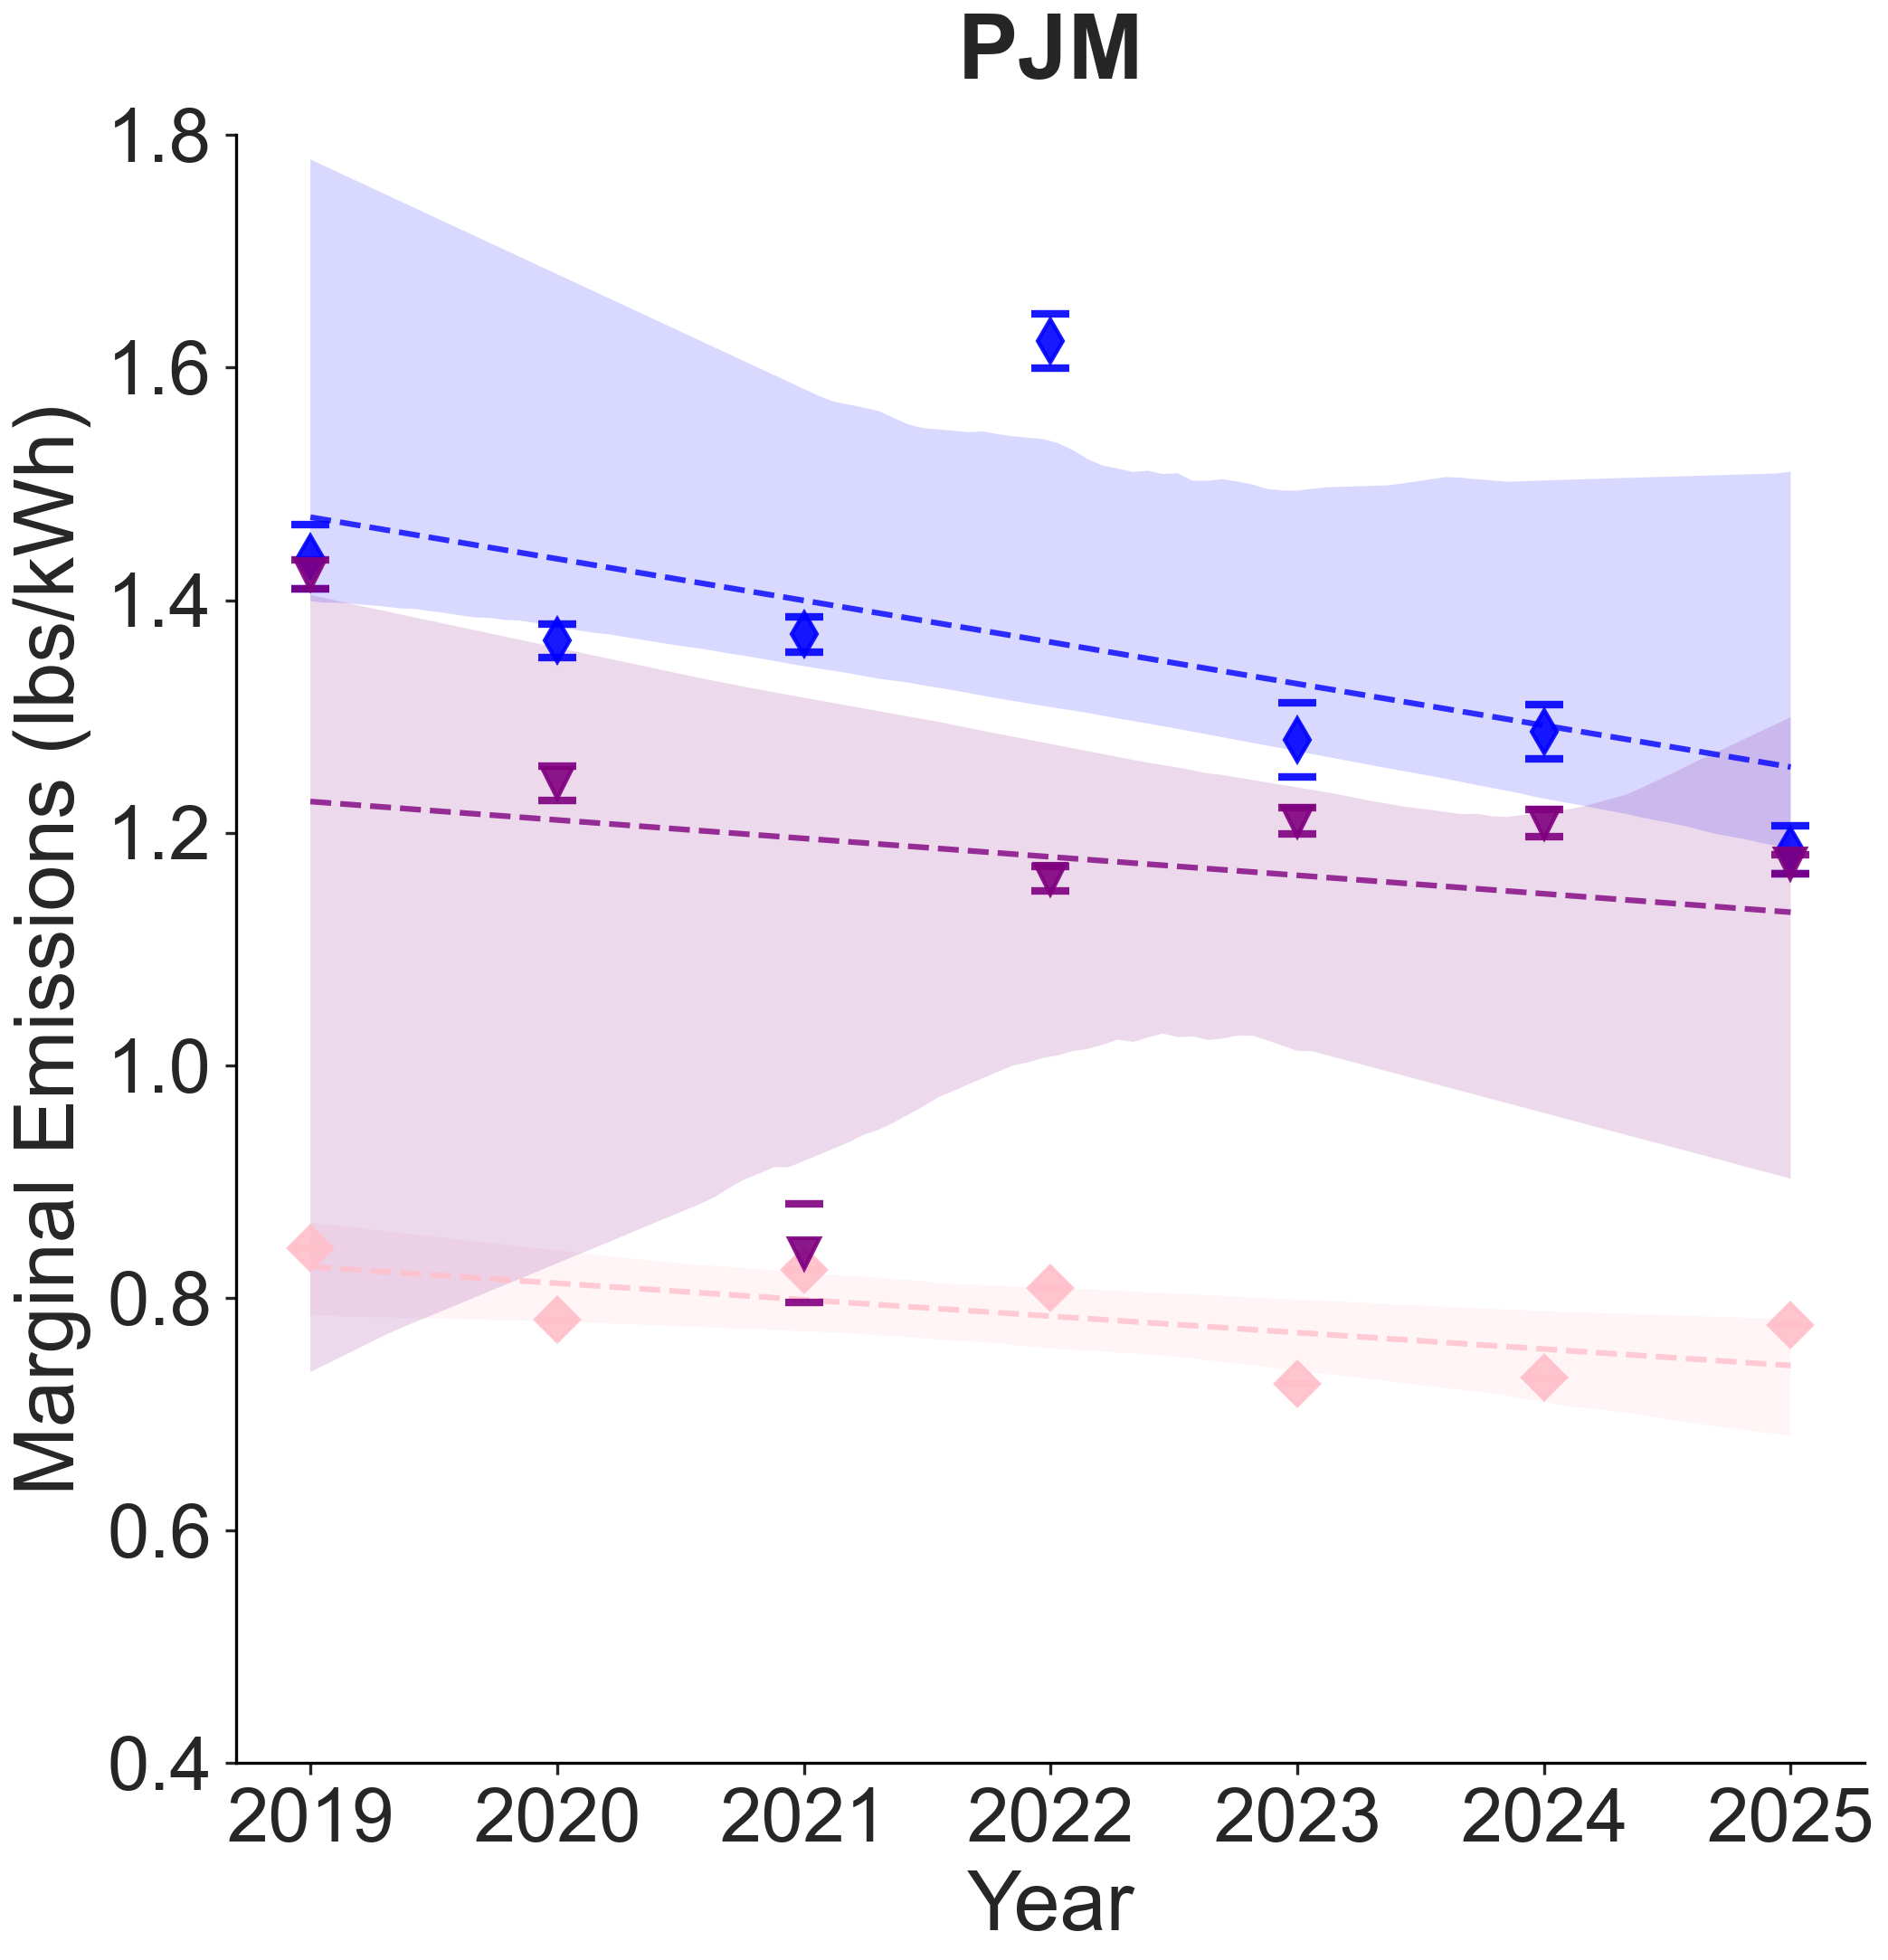

In [9]:
PJM_analysis.plot_mef_by_year(res, include_markov=True)

In [10]:
#MISO analysis
path = "DATAISOS/MISO.xlsx"
sheet_name="Published Hourly Data"
MISO_analysis = OtherZonesAnalysis(path,sheet_name=sheet_name)
MISO_analysis.load_and_clean_data()
MISO = MISO_analysis.extract_seasonality()
MISO_res = MISO_analysis.compute_msm_per_year()



Loading data from DATAISOS/MISO.xlsx...
🔧 Removing outliers (IQR) and interpolating gaps...
🧮 Calculating aggregate renewable and non-renewable generation...
✅ Data loaded and cleaned successfully.
   Date range: 2019-01-01 → 2025-12-31
   Observations: 61345
   Columns: ['Date', 'D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas', 'Gen_Nuclear', 'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil', 'Hour', 'renewable_gen', 'non_renewable_gen', 'hourly_emissions_mlb', 'hourly_generation_mkwh', 'hourly_generation_renewables_mkwh', 'hourly_generation_nonrenewables_mkwh', 'T']
Extracting seasonality...
  -> Fitting emissions...
  -> Fitting renewable gen...
  -> Fitting non renewable gen...
Seasonality extraction complete.
Computing MSM per year...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...

MSM Results:
   Year  year   OLS_MEF    OLS_SE  MS_High_MEF  MS_High_SE  MS_Low_MEF  \
0  2019  2019  1.622350  0.01

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved Generation Mix plot to images_msm/MISO_Gen.eps
Saved Generation Mix plot to images_msm/MISO_Gen.svg


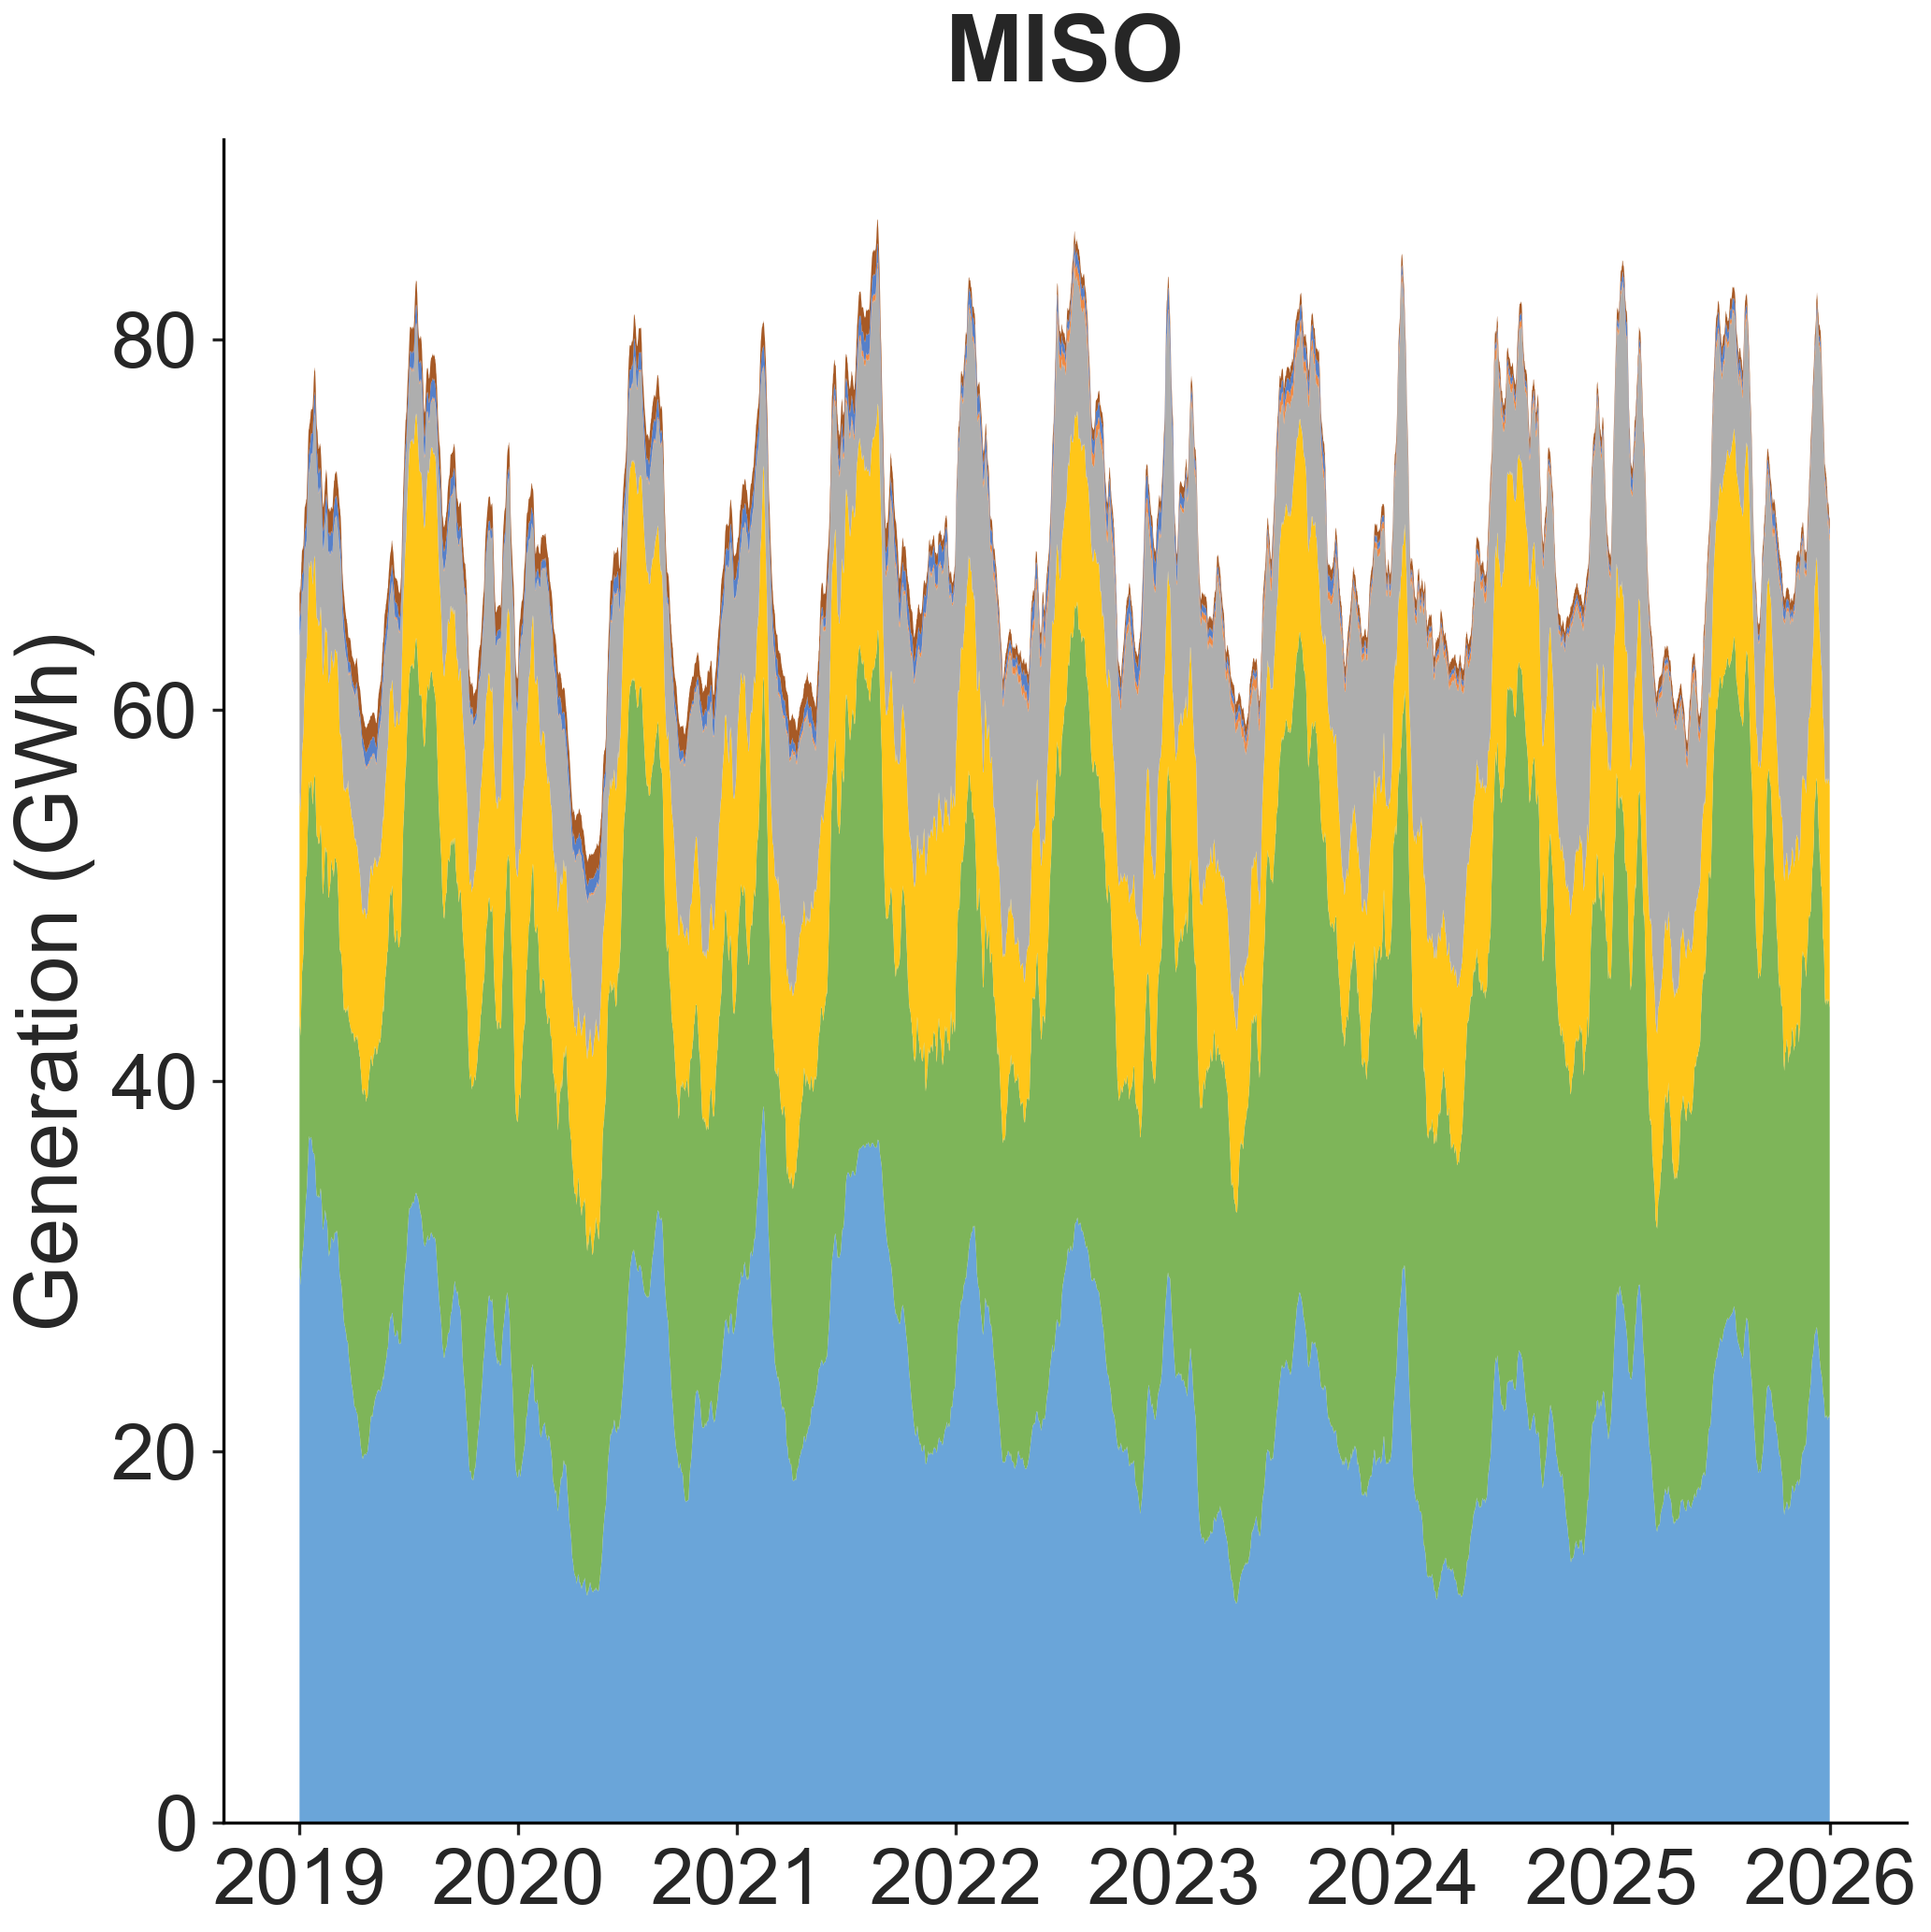

In [11]:
MISO_analysis.plot_generation_mix(show_legend=False)

In [12]:
MISO_res

,Year,year,OLS_MEF,OLS_SE,MS_High_MEF,MS_High_SE,MS_Low_MEF,MS_Low_SE,Avg_Emissions
0,2019,2019,1.622350,0.018672,1.633273,0.005972,1.370050,0.021061,1.179455
1,2020,2020,1.578087,0.025272,1.579799,0.005652,1.265437,0.016177,1.090772
2,2021,2021,1.386109,0.025872,1.467359,0.007660,1.017496,0.021805,1.145275
3,2022,2022,1.466366,0.018552,1.428532,0.006387,1.133870,0.012191,1.098950
4,2023,2023,1.546956,0.031490,1.494877,0.006256,1.262386,0.010547,1.028997
5,2024,2024,1.571849,0.018212,1.521083,0.005833,0.665081,0.019402,1.002012
6,2025,2025,1.490314,0.017116,1.428052,0.004829,1.333720,0.009699,1.052906


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved MEF plot to images_msm/MISO_MEF.eps
Saved MEF plot to images_msm/MISO_MEF.svg


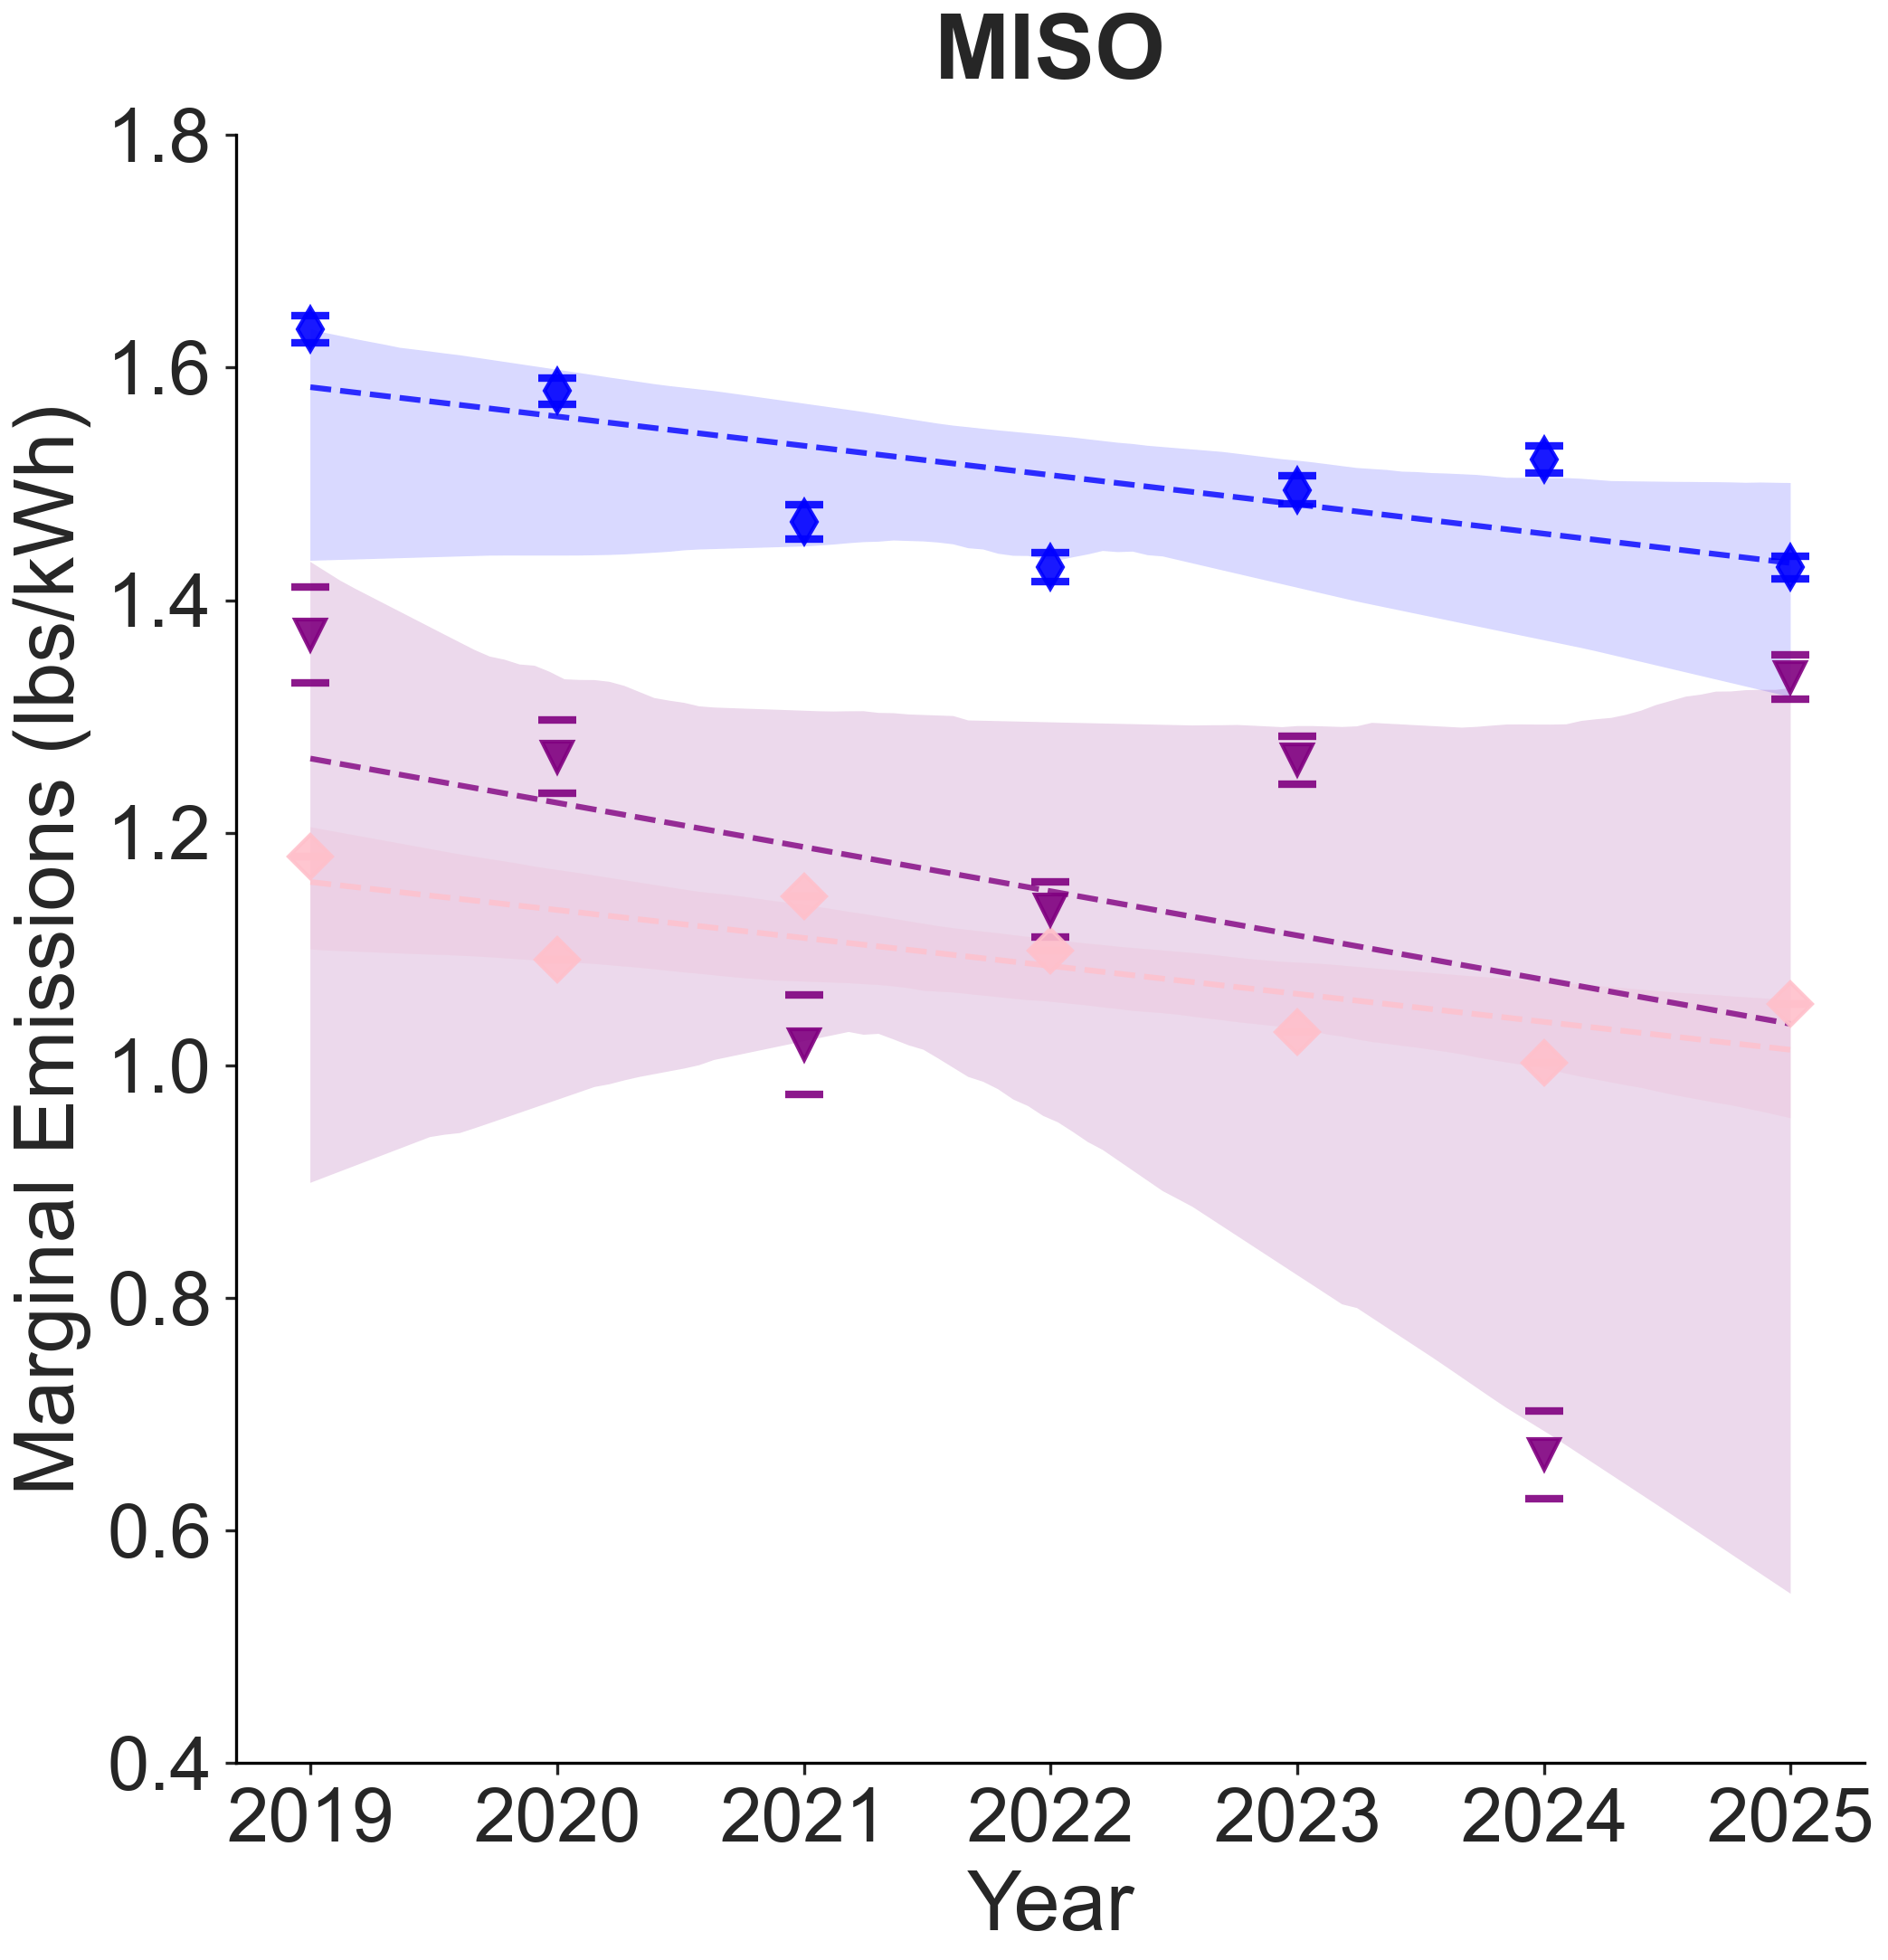

In [13]:
MISO_analysis.plot_mef_by_year(MISO_res, include_markov=True)

In [14]:
#ERCO analysis
path = "DATAISOS/ERCO.xlsx"
sheet_name="Published Hourly Data"
ERCO_analysis = OtherZonesAnalysis(path,sheet_name=sheet_name)
ERCO_analysis.load_and_clean_data()
ERCO = ERCO_analysis.extract_seasonality()
ERCO_res = ERCO_analysis.compute_msm_per_year()

Loading data from DATAISOS/ERCO.xlsx...
🔧 Removing outliers (IQR) and interpolating gaps...
🧮 Calculating aggregate renewable and non-renewable generation...
✅ Data loaded and cleaned successfully.
   Date range: 2019-01-01 → 2025-12-31
   Observations: 61345
   Columns: ['Date', 'D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas', 'Gen_Nuclear', 'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil', 'Hour', 'renewable_gen', 'non_renewable_gen', 'hourly_emissions_mlb', 'hourly_generation_mkwh', 'hourly_generation_renewables_mkwh', 'hourly_generation_nonrenewables_mkwh', 'T']
Extracting seasonality...
  -> Fitting emissions...
  -> Fitting renewable gen...
  -> Fitting non renewable gen...
Seasonality extraction complete.
Computing MSM per year...
Processing 2019...
Processing 2020...
Processing 2021...
Processing 2022...
Processing 2023...
Processing 2024...
Processing 2025...

MSM Results:
   Year  year   OLS_MEF    OLS_SE  MS_High_MEF  MS_High_SE  MS_Low_MEF  \
0  2019  2019  1.194152  0.01

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved Generation Mix plot to images_msm/ERCO_Gen.eps
Saved Generation Mix plot to images_msm/ERCO_Gen.svg


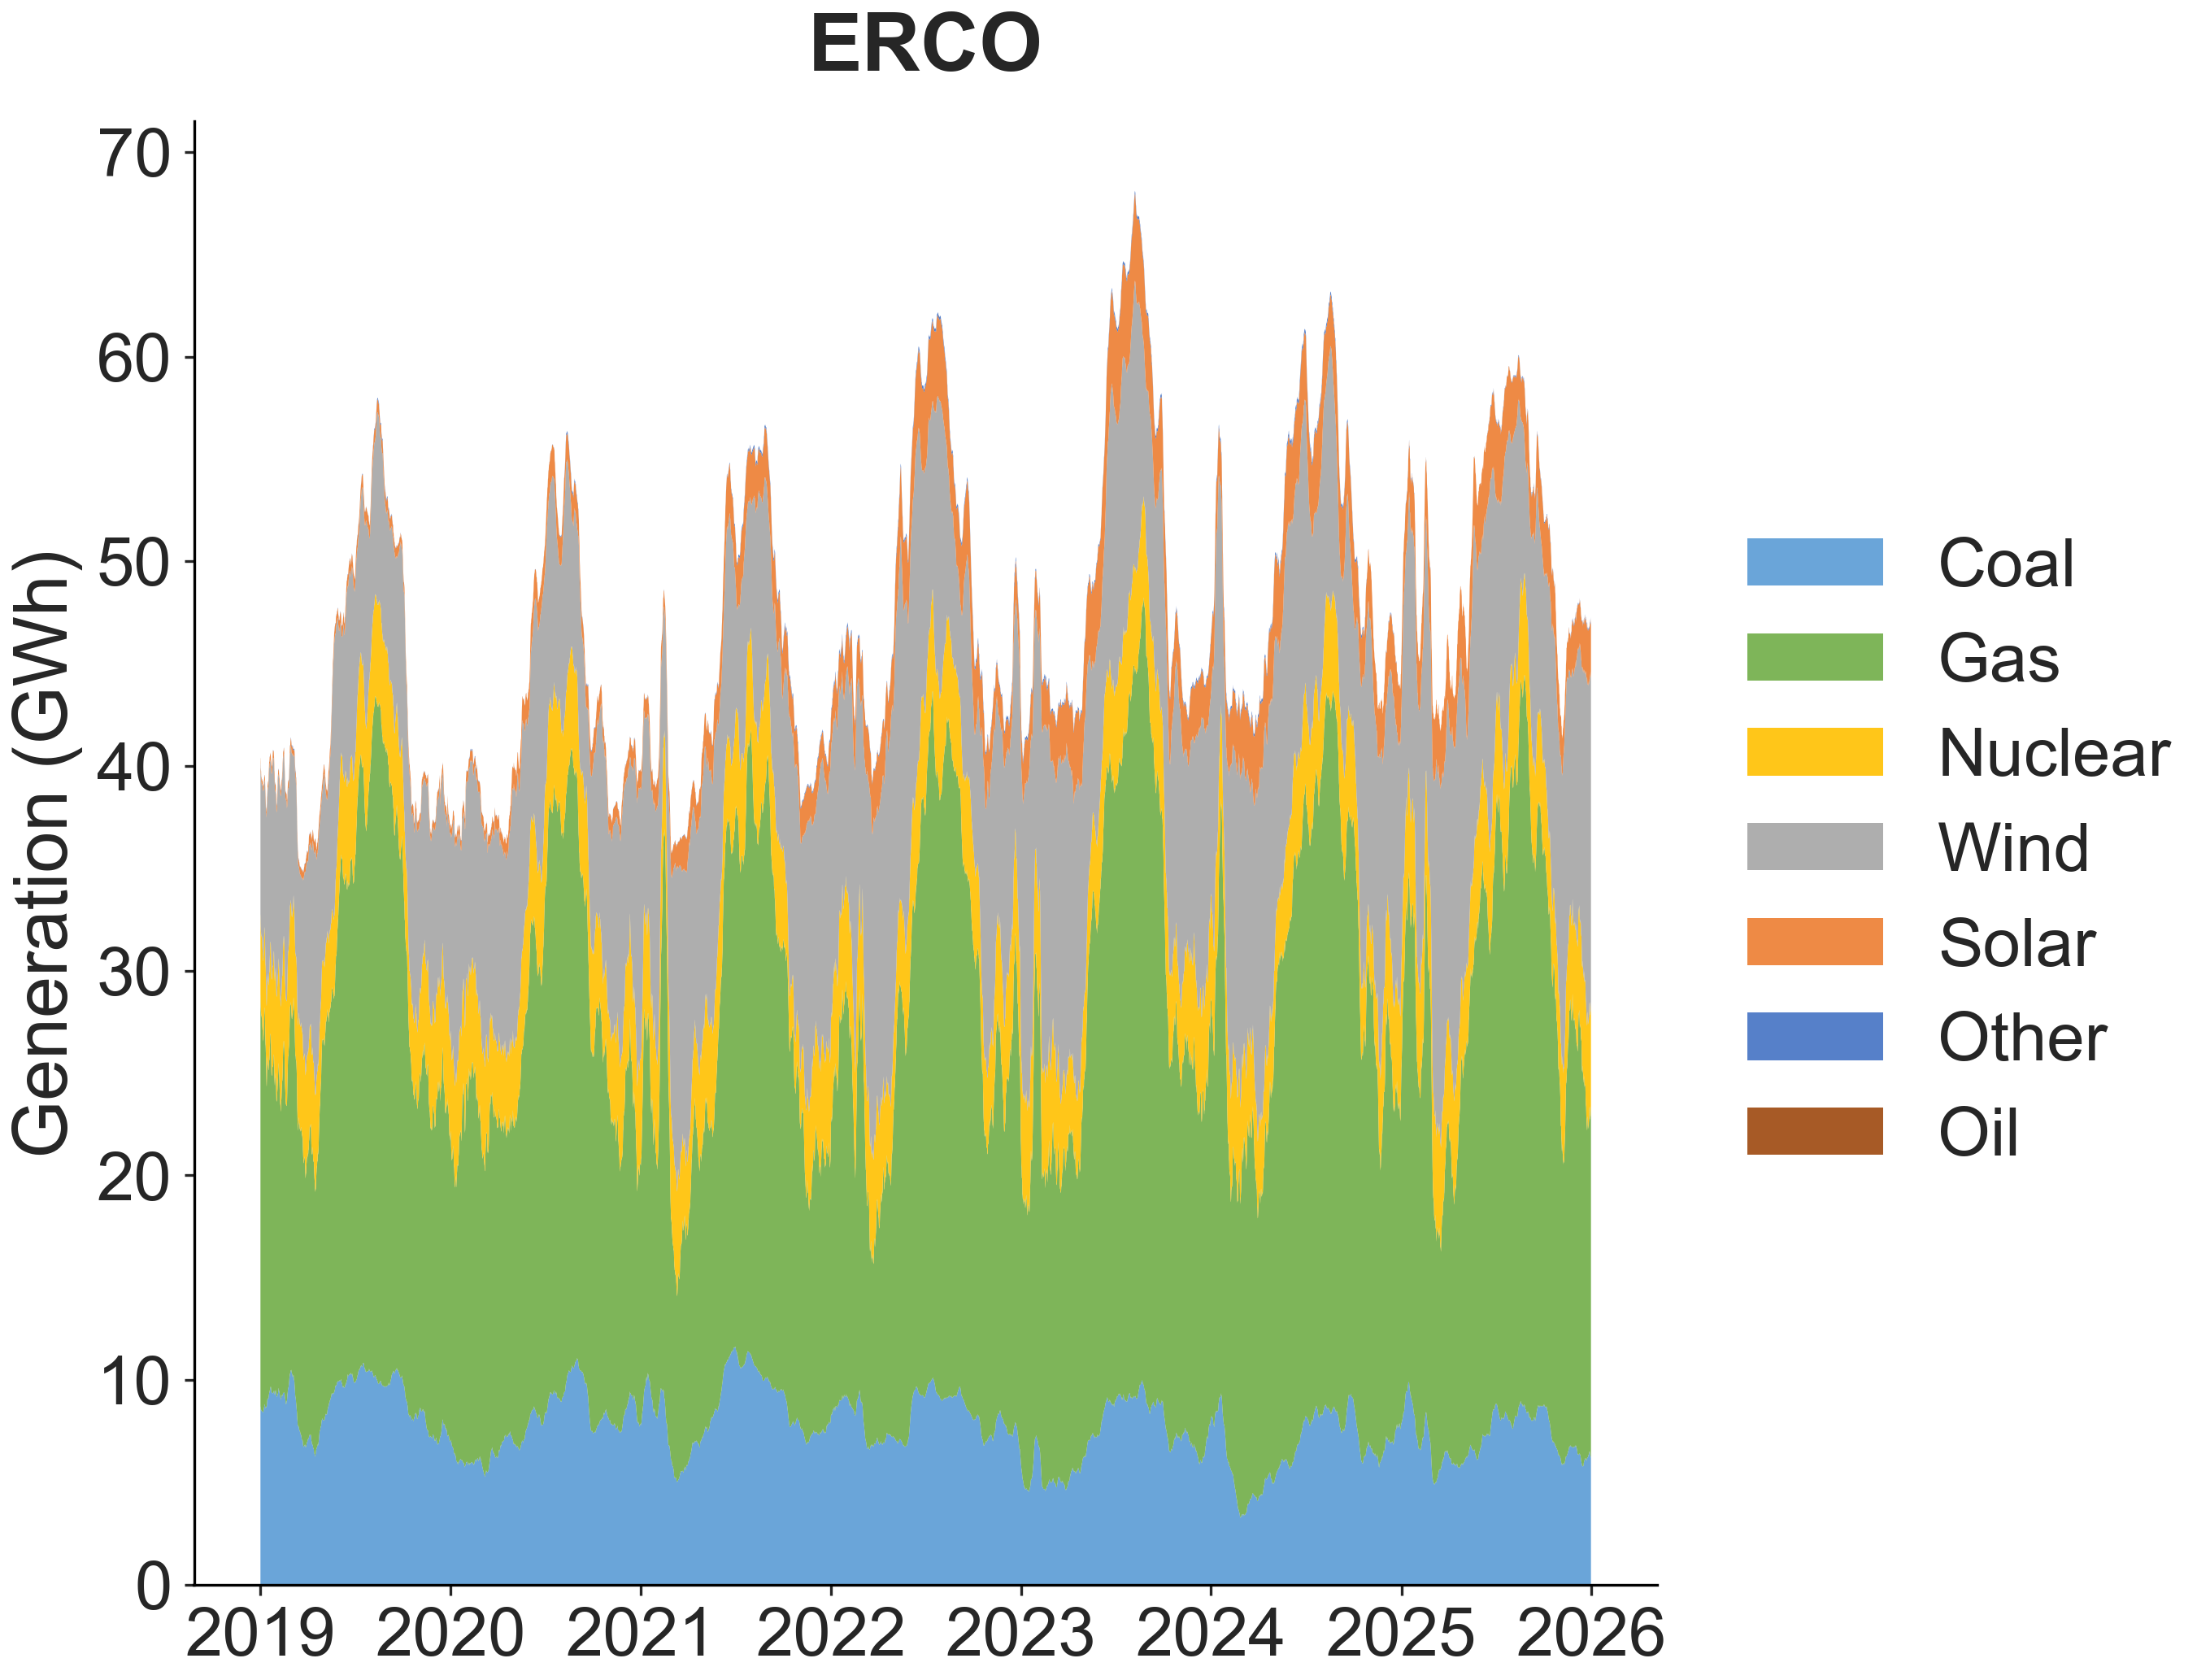

In [20]:
ERCO_analysis.plot_generation_mix(show_legend=True)

In [16]:
ERCO_res

,Year,year,OLS_MEF,OLS_SE,MS_High_MEF,MS_High_SE,MS_Low_MEF,MS_Low_SE,Avg_Emissions
0,2019,2019,1.194152,0.019287,1.276126,0.007833,1.060574,0.011624,0.903522
1,2020,2020,1.173579,0.024932,1.299561,0.009249,1.008380,0.022816,0.837333
2,2021,2021,1.095995,0.015671,1.209137,0.009264,1.001133,0.013084,0.831458
3,2022,2022,1.074693,0.011633,1.219472,0.010420,0.995431,0.008933,0.783929
4,2023,2023,1.213199,0.012875,1.254248,0.008482,1.238706,0.006412,0.762959
5,2024,2024,1.182447,0.012164,1.179261,0.004626,1.156347,0.011461,0.750122
6,2025,2025,1.156718,0.006875,1.246747,0.005001,1.104657,0.005306,0.761840


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


Saved MEF plot to images_msm/ERCO_MEF.eps
Saved MEF plot to images_msm/ERCO_MEF.svg


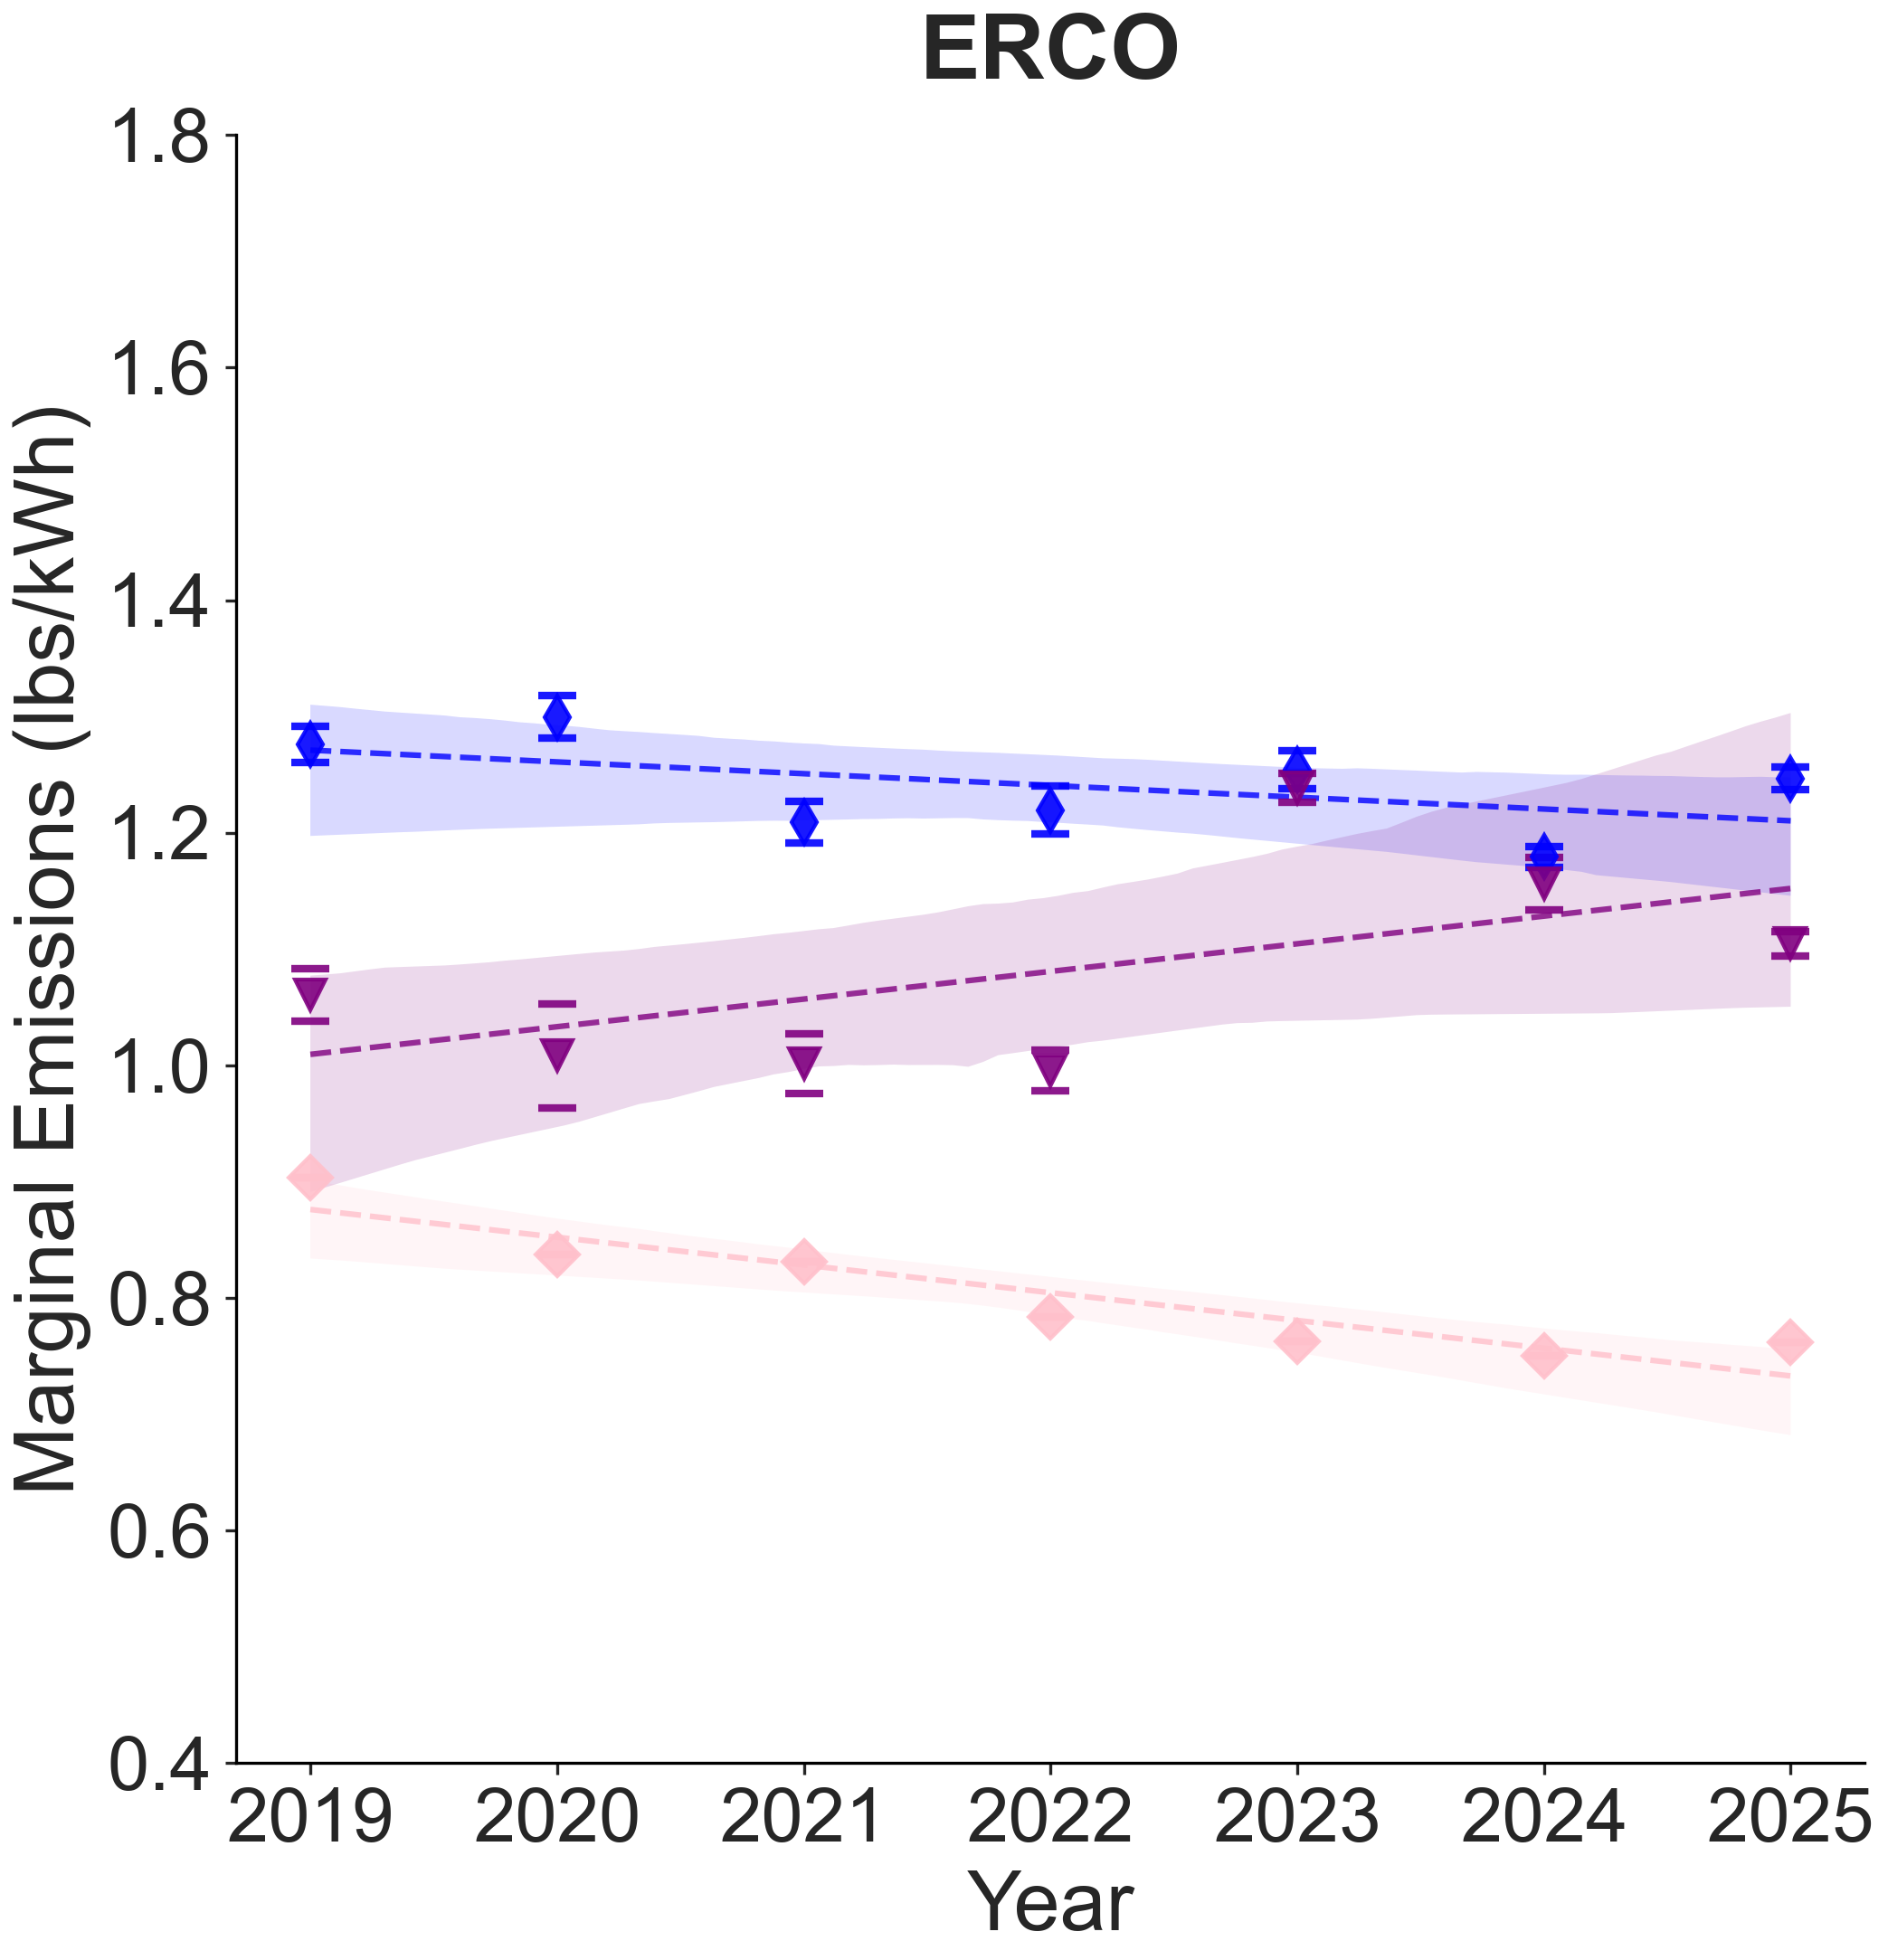

In [19]:
ERCO_analysis.plot_mef_by_year(ERCO_res, include_markov=True)

In [18]:
path = "DATAISOS/CISO.xlsx"
sheet_name = "Published Hourly Data"
CISO_analysis = OtherZonesAnalysis(path, sheet_name=sheet_name)
CISO_analysis.load_and_clean_data()
CISO = CISO_analysis.extract_seasonality()
CISO_res = CISO_analysis.compute_msm_per_year()

Loading data from DATAISOS/CISO.xlsx...
🔧 Removing outliers (IQR) and interpolating gaps...
🧮 Calculating aggregate renewable and non-renewable generation...
✅ Data loaded and cleaned successfully.
   Date range: 2019-01-01 → 2025-12-31
   Observations: 61345
   Columns: ['Date', 'D', 'NG', 'daily_emissions', 'Gen_Coal', 'Gen_Gas', 'Gen_Nuclear', 'Gen_Wind', 'Gen_Sun', 'Gen_Others', 'Gen_Oil', 'Hour', 'renewable_gen', 'non_renewable_gen', 'hourly_emissions_mlb', 'hourly_generation_mkwh', 'hourly_generation_renewables_mkwh', 'hourly_generation_nonrenewables_mkwh', 'T']
Extracting seasonality...
  -> Fitting emissions...
  -> Fitting renewable gen...
  -> Fitting non renewable gen...
Seasonality extraction complete.
Computing MSM per year...
Processing 2019...
  -> MSM failed for 2019: SVD did not converge
Processing 2020...
  -> MSM failed for 2020: SVD did not converge
Processing 2021...
Processing 2022...
Processing 2023...
  -> MSM failed for 2023: SVD did not converge
Processing 202